### Blood subtypes

In [1]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(destiny))


#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here("mapping/run/mnn/mapping_functions.R"))

args = list()
args$sce <- io$rna.sce
#args$stage <- c('E9.5')#, 'E8.5', 'E9.5')
args$metadata <- paste0(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$atlas_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/sample_metadata.txt.gz"
args$cdr_threshold = 0.1
args$logFC_thr = 1
args$outdir <- paste0(io$basedir,"/results/rna/differential")
args$metascape = file.path(args$outdir, 'metascape')
# If passing multiple timepoints split in vector
#args$stage = strsplit(args$stage, "_")[[1]] 

dir.create(args$metascape, recursive=TRUE, showWarnings = FALSE)

### Functions
# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
# Reversing vector order (for pseudotime)
reverse = function(x){-x + max(x) + min(x)}

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/code



In [42]:
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)


In [2]:
set.seed(1234)

In [3]:
ct_blood = c('Haematoendothelial_progenitors',
             'Blood_progenitors',
             'Erythroid')


##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
    .[, celltype.mapped_mnn:=celltype_extended.mapped_mnn] %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & celltype.mapped_mnn %in% ct_blood] %>%
    .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)]


# if(test){
#     sample_metadata = sample_metadata[sample(1:nrow(sample_metadata), nrow(sample_metadata)/4)]
# }

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [4]:
# Filter genes
# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(sce)] %>%
  .[!duplicated(symbol)]

# Imprinted genes
imprint = gene_metadata[c(grep('maternally', gene_metadata$description),
                       grep('paternally', gene_metadata$description)), symbol]


genes_keep = rownames(sce) %>%
    .[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",.,invert=T)] %>% # filter out non-informative genes
    .[grep("^Hbb|^Hba",.,invert=T)] %>% # Removing Haem genes due to spilling over from erythroids to other cells 
    .[!. %in% c(imprint, 'Grb10', 'Nnat')] %>%  # remove imprinted genes
    .[!. %in% c("Xist", "Tsix")] %>%  # remove Xist & Tsix
    .[!.=="tomato-td"] %>% # remove tomato itself
    .[!.%in%gene_metadata[chr=="chrY",symbol]]

sce = sce[genes_keep,]

In [5]:
CDR = data.table(gene = rownames(sce),
                 cdr_WT = rowMeans(counts(sce[,colData(sce)$tdTom_corr==FALSE])>0),
                 cdr_KO = rowMeans(counts(sce[,colData(sce)$tdTom_corr==TRUE])>0)) %>%
    .[order(-cdr_WT)] %>%
    .[,pass_CDR := ifelse(cdr_WT > args$cdr_threshold | cdr_KO > args$cdr_threshold, TRUE, FALSE)]

In [6]:
head(CDR[pass_CDR==TRUE, gene])

[1] "Cox5b"  "Hspd1"  "Hspe1"  "Eef1b2" "Ncl"    "Ptma"

In [7]:
tail(CDR[pass_CDR==TRUE], 10)

gene,cdr_WT,cdr_KO,pass_CDR
<chr>,<dbl>,<dbl>,<lgl>
Lcorl,0.048420330,0.1165514,TRUE
Suco,0.048076923,0.1309207,TRUE
Kif3b,0.044642857,0.1075040,TRUE
Uty,0.037087912,0.1447578,TRUE
Osbpl1a,0.036401099,0.1101650,TRUE
Xlr3b,0.027129121,0.1021820,TRUE
Baiap2l1,0.013392857,0.1240021,TRUE
Zfp985,0.009958791,0.1463544,TRUE
Hopx,0.001030220,0.1883981,TRUE


In [8]:
#######################
## Feature selection ##
#######################
args$features = 2000

decomp <- modelGeneVar(sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% 
    as.data.table(., keep.rownames=T) %>% 
     head(n=args$features) %>% .$rn

# Subset HVGs
sce_filt <- sce[hvgs,]
dim(sce_filt)

sce_filt <- runPCA(sce_filt, ncomponents = 5, ntop=nrow(sce_filt))

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


[1] 2000 4791

In [9]:
reducedDim(sce, "PCA") = reducedDim(sce_filt, "PCA")
pca = as.data.frame(reducedDim(sce_filt, "PCA"))

In [10]:
dm <- DiffusionMap(pca, n_pcs=3)
# Add to the SingleCellExperiment object
reducedDim(sce, "DiffusionMap") <- dm@eigenvectors[,c(1,2)]

Warning message:
“as(<dsCMatrix>, "dsTMatrix") is deprecated since Matrix 1.5-0; do as(., "TsparseMatrix") instead”


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


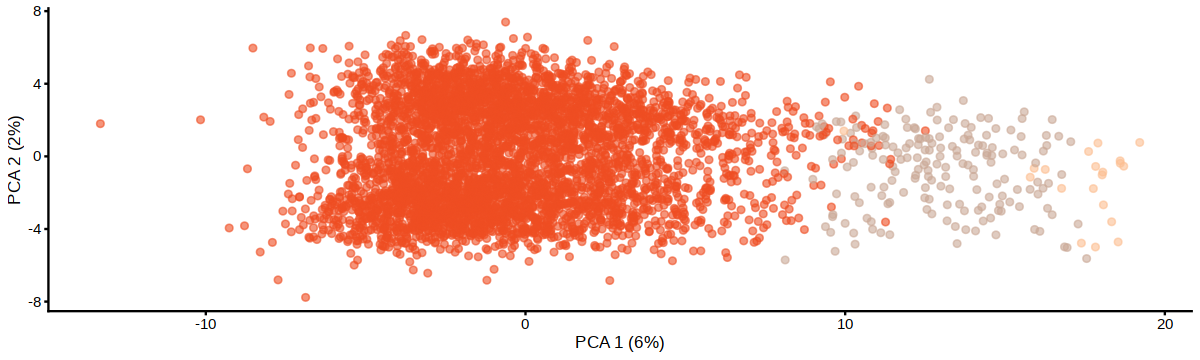

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


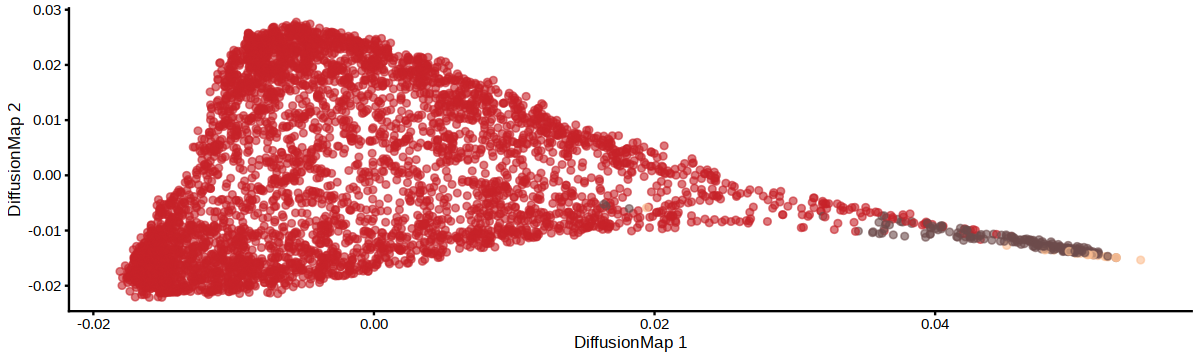

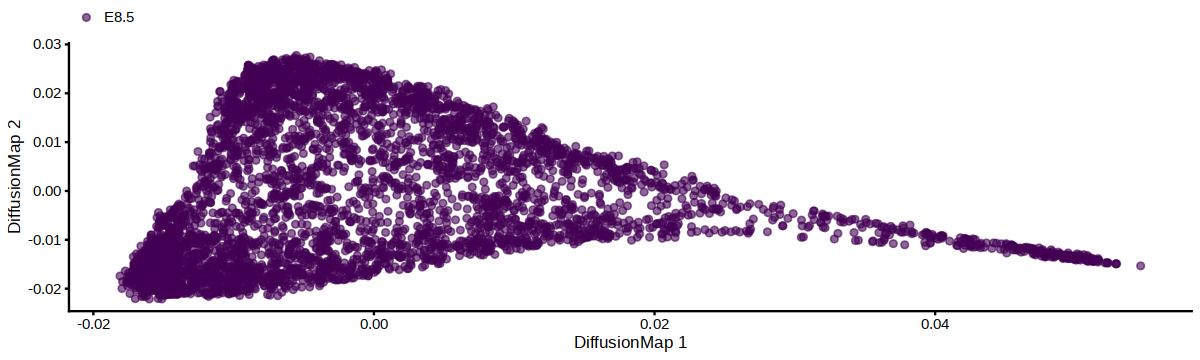

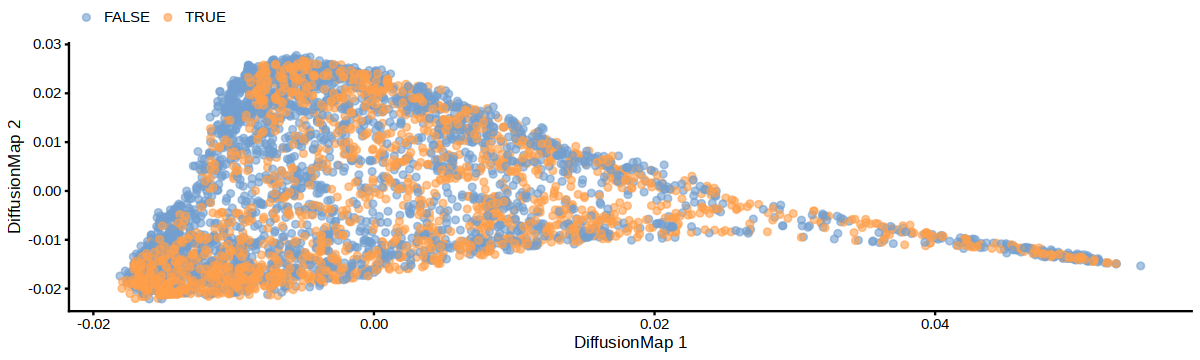

In [11]:
# Plot
options(repr.plot.width=10, repr.plot.height=3)
plotReducedDim(sce, dimred = "PCA", colour_by="celltype.mapped_mnn", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$celltype.colors) + theme(legend.position="none")

plotReducedDim(sce, dimred = "DiffusionMap", colour_by="celltype.mapped_mnn", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$celltype_extended.colors) + theme(legend.position="none")

plotReducedDim(sce, dimred = "DiffusionMap", colour_by="stage", ncomponents = c(1,2)) +
  scale_colour_manual(values=opts$stage.colors) + theme(legend.position="top", legend.title = element_blank())

plotReducedDim(sce, dimred = "DiffusionMap", colour_by="tdTom_corr", ncomponents = c(1,2)) +
  theme(legend.position="top", legend.title = element_blank())

# Pseudotime inference
https://www.bioconductor.org/packages/release/bioc/vignettes/tradeSeq/inst/doc/tradeSeq.html
https://www.bioconductor.org/packages/release/bioc/manuals/tradeSeq/man/tradeSeq.pdf

In [12]:
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(BiocParallel))
suppressPackageStartupMessages(library(circlize))

In [13]:
# reducedDim(sce_filt, "PCA") = pca.corrected

In [14]:
reducedDim(sce, "PCA") = pca

In [15]:
sce <- slingshot(sce, reducedDim='PCA')
head(sce$slingPseudotime_1)

No cluster labels provided. Continuing with one cluster.



[1] 19.74376 20.93390 21.80965 20.07629 20.53542 18.69047

In [16]:
embedded <- embedCurves(sce, "DiffusionMap")
embedded <- slingCurves(embedded)[[1]] # only 1 path.
embedded <- data.frame(embedded$s[embedded$ord,])

In [17]:
meta = as.data.table(colData(sce)[,-grep('slingshot', colnames(colData(sce)))], keep.rownames=T) %>% setnames('rn', 'cell') %>% 
    .[, pseudotime := reverse(slingPseudotime_1)] #%>%
  #  .[, pseudotime := minmax(pseudotime)]

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


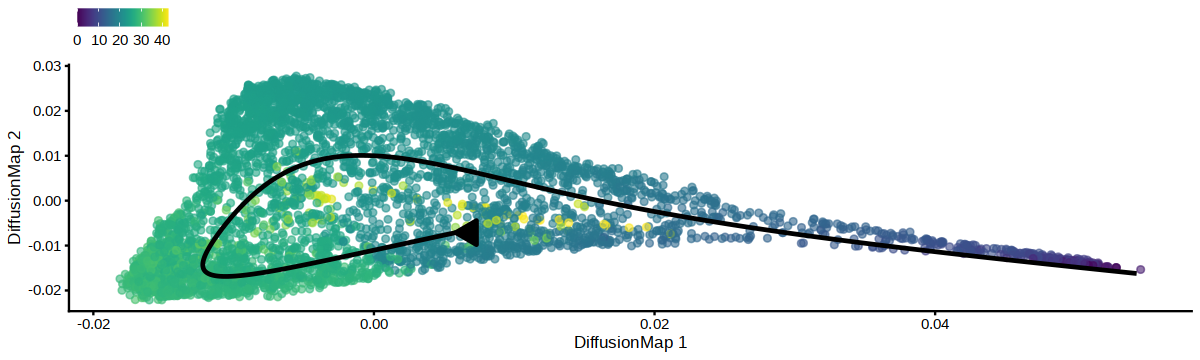

In [18]:
colData(sce) <- meta %>% tibble::column_to_rownames("cell") %>% DataFrame

plotReducedDim(sce, dimred = "DiffusionMap", colour_by="pseudotime", ncomponents = c(1,2)) +
    geom_path(data=embedded, 
              aes(x=DC1, y=DC2), 
              size=1, 
              arrow=grid::arrow(ends = 'first', type = 'closed', length = unit(0.20, "inches"))) + 
    theme(legend.position="top", legend.title = element_blank())

In [19]:
minmax.normalisation

function (x) 
{
    return((x - min(x, na.rm = T))/(max(x, na.rm = T) - min(x, 
        na.rm = T)))
}

In [29]:
# Instead, replace pseudotime with just the DM1
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame
sce$pseudotime = reverse(minmax(as.vector(sce@int_colData$reducedDims$DiffusionMap[,'DC1'])))
meta = as.data.table(colData(sce), keep.rownames=T) %>% setnames('rn', 'cell')


Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


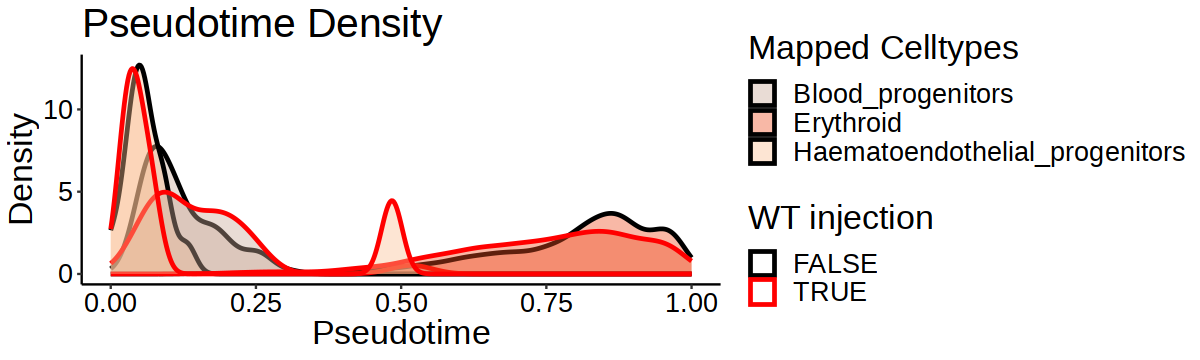

In [30]:
ggplot(meta, aes(pseudotime, col=tdTom_corr, fill=celltype.mapped_mnn)) + 
    geom_density(alpha=0.4, size=1) + 
    scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='WT injection') + 
    scale_fill_manual(values = opts$celltype.colors, name='Mapped Celltypes') +
    ggtitle('Pseudotime Density') + 
    xlab('Pseudotime') + ylab('Density') + 
    theme_classic() + 
    theme(text = element_text(size=20),
          axis.text = element_text(color='black'))

In [31]:
# subset sce_filt 
sce_filt = sce[, meta$cell]

# Trade-seq

In [32]:
sce_filt = sce_filt[CDR[pass_CDR==TRUE, gene], ]

In [33]:
meta_filt = meta[tdTom==tdTom_corr]
sce_filt = sce_filt[,meta_filt$cell]

In [34]:
dim(counts(sce_filt))

[1] 7042 4789

In [35]:
# Set parallel cores
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.

Fitting lineages with multiple conditions. This 

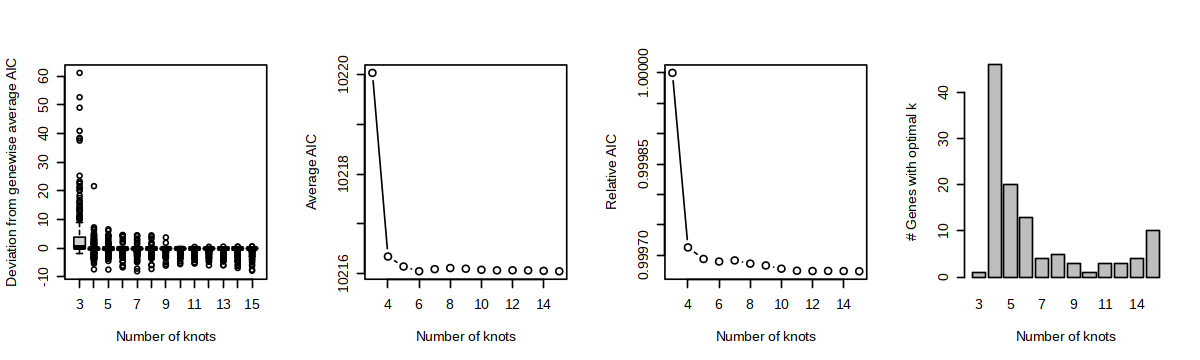

In [86]:
options(repr.plot.width = 10, repr.plot.height=3)
icMat <- evaluateK(counts = as.matrix(assays(sce_filt)$counts),
                   pseudotime = sce_filt$pseudotime,
                   cellWeights = rep(1,ncol(sce_filt)),
                   conditions = factor(colData(sce)$tdTom_corr),
                   nGenes = 300,
                   parallel = TRUE,
                   BPPARAM=BPPARAM,
                   k = 3:15,
                   verbose = FALSE)

In [36]:
# Set all cells to belong to one trajectory
cellWeights <- rep(1,ncol(sce_filt))

# create a model matrix -> Comparing within Embryo pools
U <- model.matrix(~sce_filt$pool)

In [104]:
# # Set parallel cores
# BPPARAM <- BiocParallel::bpparam()
# BPPARAM$workers = 1

In [38]:
sceGAM <- fitGAM(counts = counts(sce_filt),
                 conditions = as.factor(colData(sce_filt)$tdTom_corr),
                 U = U,
                 pseudotime= round(colData(sce_filt)$pseudotime,2),
                 cellWeights=cellWeights,
                 nknots=4, # put at 6!
                 parallel = TRUE,
                 BPPARAM=BPPARAM,
                 verbose=F)

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.



In [40]:
io$outdir

NULL

In [43]:
saveRDS(sceGAM, paste0(args$outdir,"/sceGAM.rds"))

In [44]:
# Test if l2fc should be changed around? Higher than 0.75 rather than lower
condRes <- conditionTest(sceGAM, l2fc = args$logFC_thr)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [45]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [46]:
condRes[gene == 'Krt15']

gene,waldStat,df,pvalue,padj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>


In [47]:
nrow(condRes[sig==TRUE])
tail(condRes[sig==TRUE], 10)

[1] 13

gene,waldStat,df,pvalue,padj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Baiap2l1,85.03246,3,0.000000e+00,0.000000e+00,TRUE
Cdkn1c,65.90691,2,4.884981e-15,6.879031e-12,TRUE
Ddx3y,72.39317,4,7.105427e-15,8.338219e-12,TRUE
Zfp985,53.88454,2,1.991185e-12,2.002848e-09,TRUE
Akr1e1,52.78330,2,3.453460e-12,3.039476e-09,TRUE
Kcnq1ot1,46.70689,4,1.755044e-09,1.373030e-06,TRUE
Hopx,38.65809,3,2.050648e-08,1.443861e-05,TRUE
Cdk5rap1,33.66521,2,4.894323e-08,3.132811e-05,TRUE
Eif2s3y,33.59713,4,9.012804e-07,5.288263e-04,TRUE


In [48]:
plot_traj = function(gene, size=0.2, alpha=0.3){
    ggplot(as.data.frame(colData(sce_filt)[,-20]), aes(pseudotime, as.vector(logcounts(sce_filt[gene,])), col=tdTom_corr)) + 
        geom_point(size=size, alpha=alpha) + 
        geom_smooth() + 
        scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
        ylab('logcounts') + 
        xlab('Pseudotime') + 
        ggtitle(gene) + 
        theme_bw() + 
        theme(text=element_text(size=20))
}

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


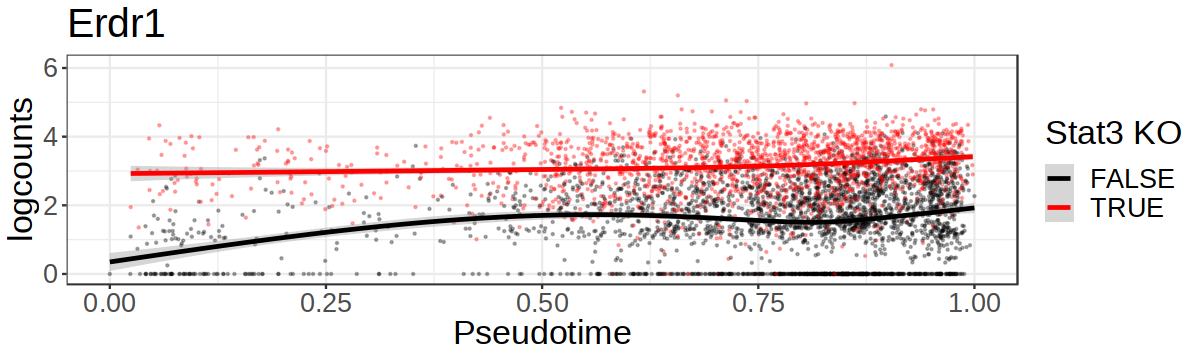

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


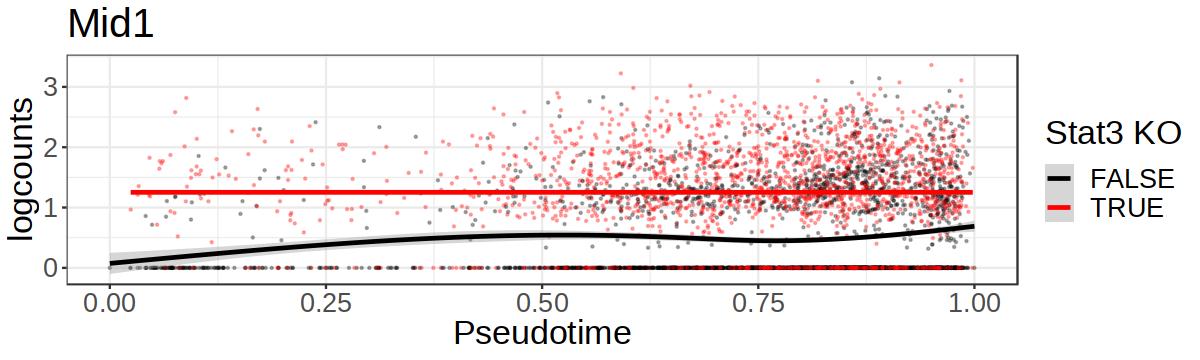

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


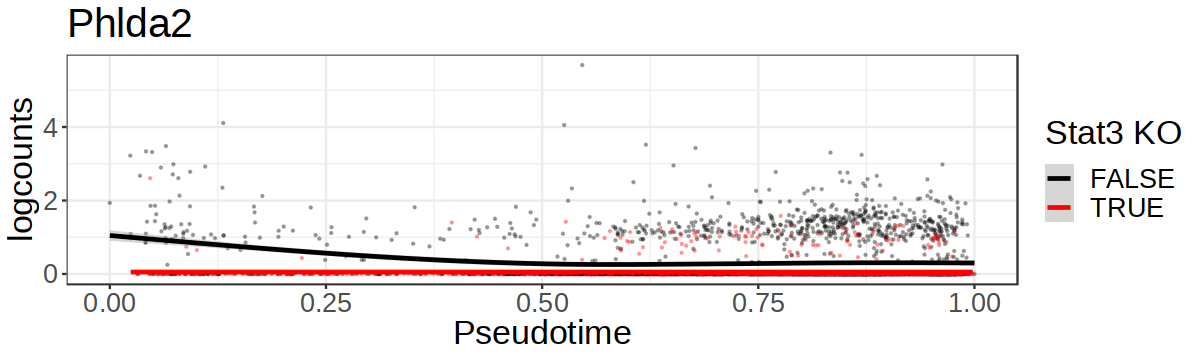

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


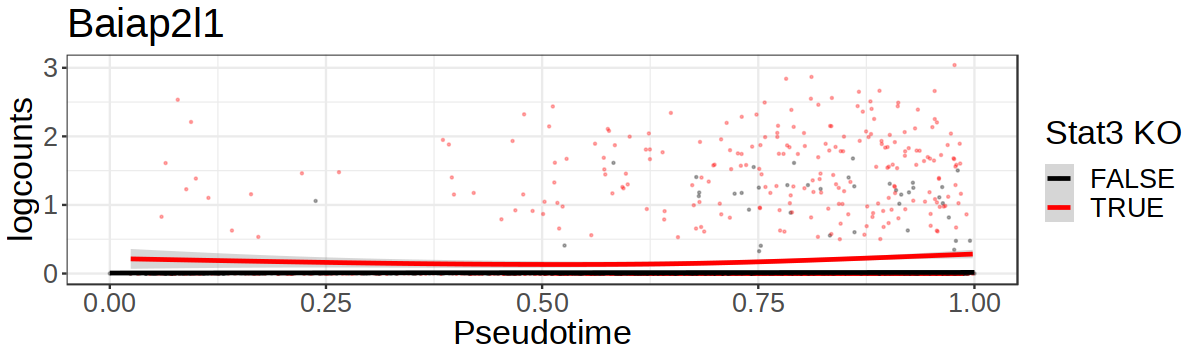

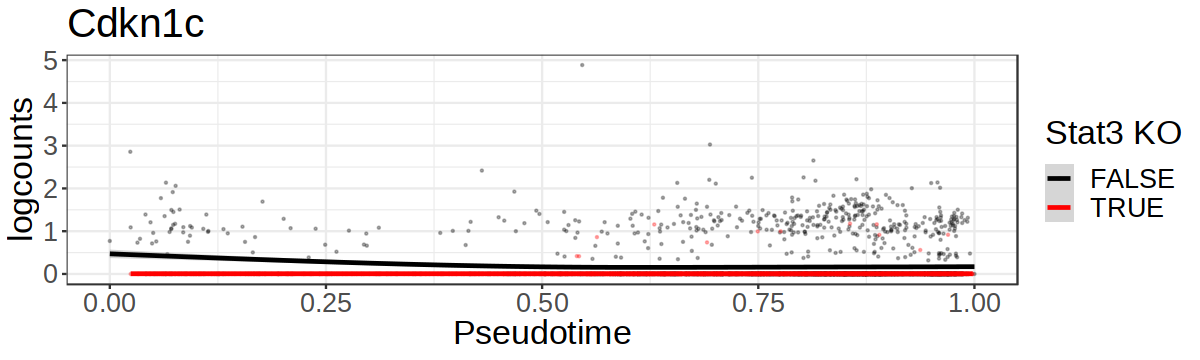

In [49]:
options(repr.plot.width = 10, repr.plot.height=3)
mclapply(head(condRes$gene, 5), plot_traj, mc.cores=24)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


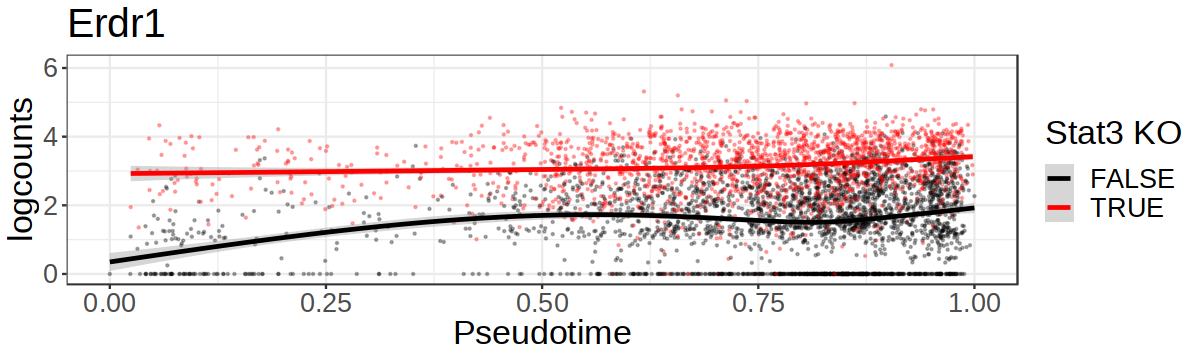

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


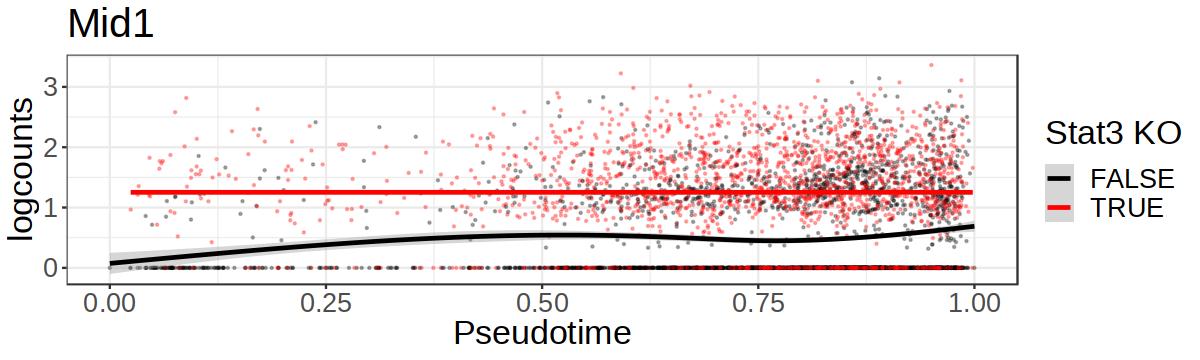

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


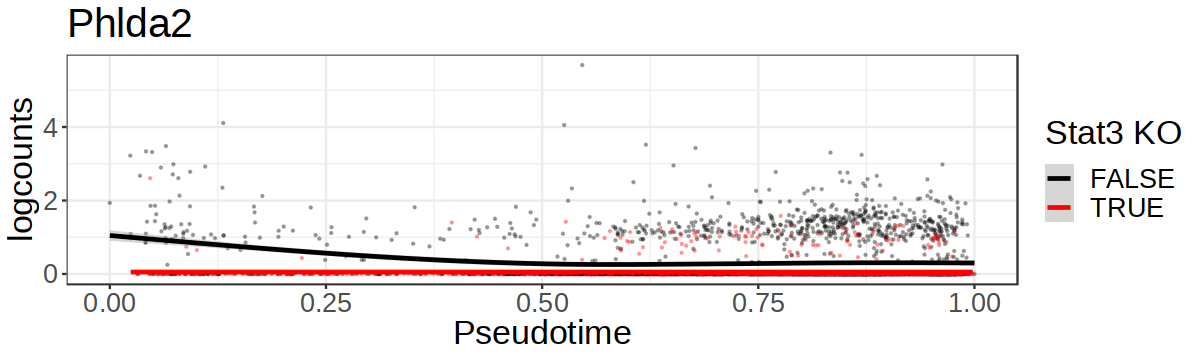

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


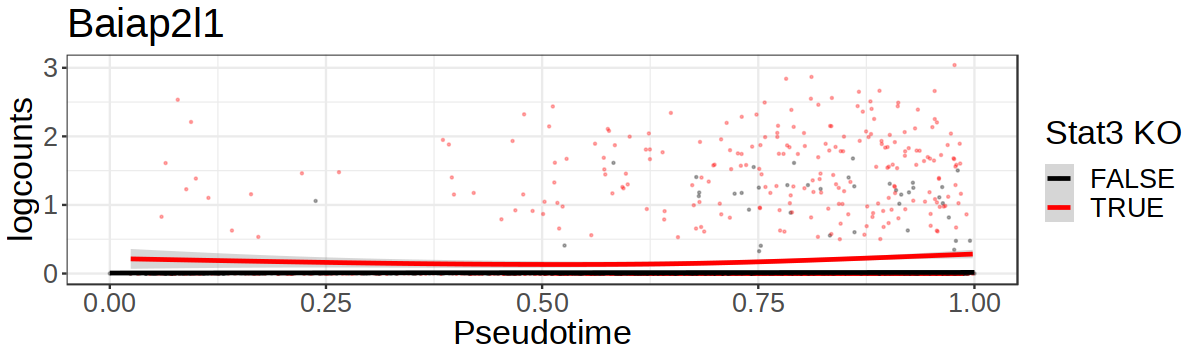

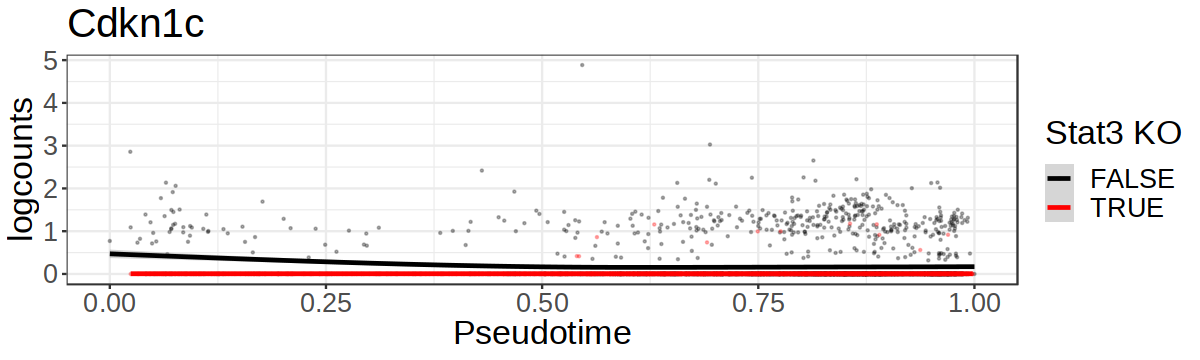

In [50]:
options(repr.plot.width = 10, repr.plot.height=3)
mclapply(head(condRes$gene, 5), plot_traj, mc.cores=24)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


[[1]]

[[2]]


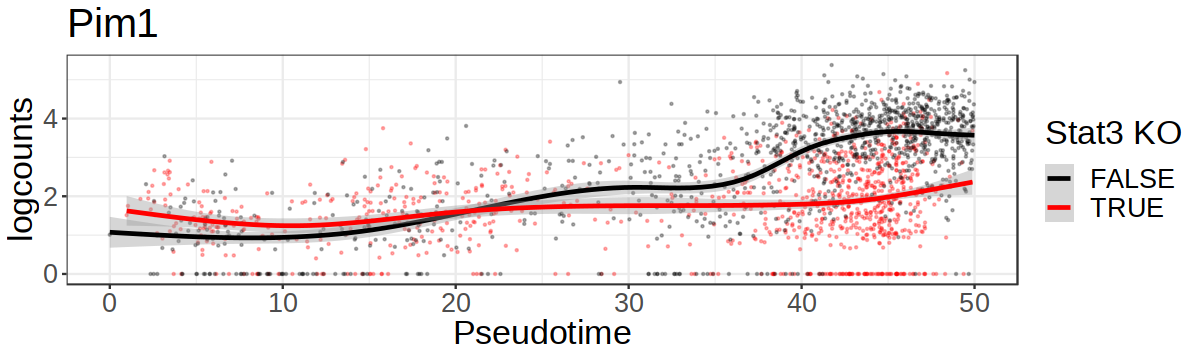

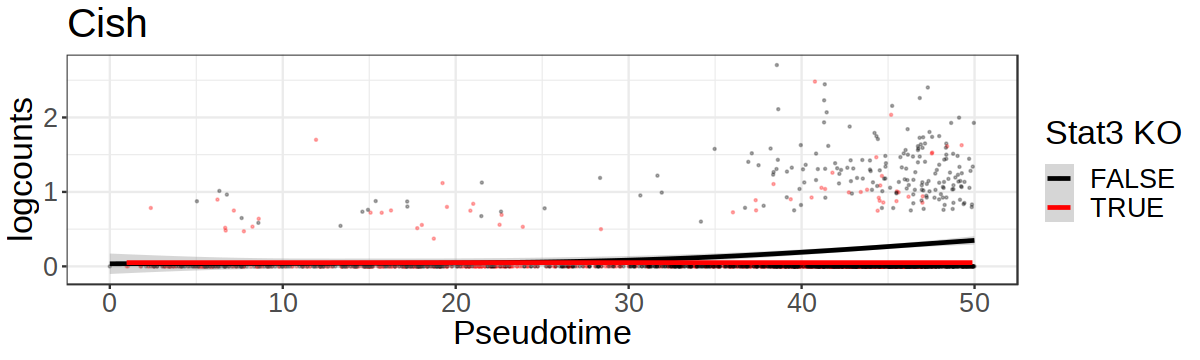

In [246]:
options(repr.plot.width = 10, repr.plot.height=3)
mclapply(c('Pim1', 'Cish'), plot_traj, mc.cores=24)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


[[1]]


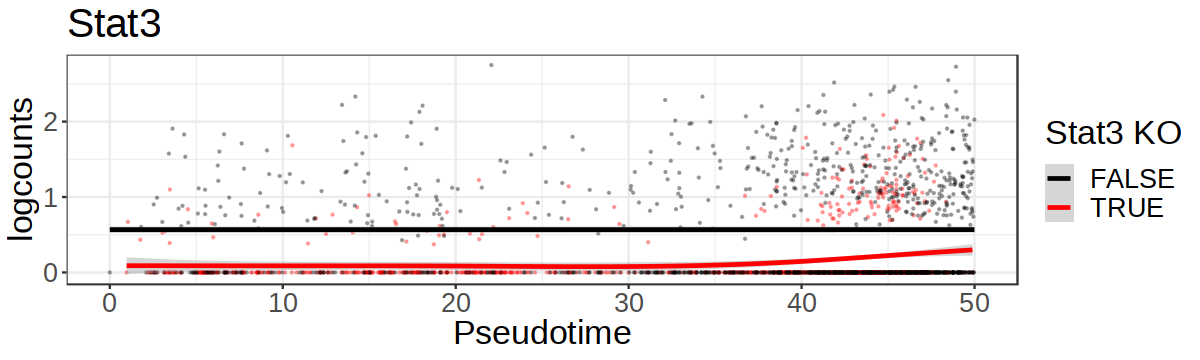

In [247]:
mclapply(c('Stat3'), plot_traj, mc.cores=24)

In [303]:
trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')
cols <- trans(seq(0,1, length.out=20))

In [304]:
col_fun = colorRamp2(seq(0, 50, 5), viridis::viridis(length(seq(0, 50, 5))))

In [47]:
ha = HeatmapAnnotation(pseudotime = 1:50,
                       col = list(pseudotime = col_fun))

In [48]:
length(condRes[sig==TRUE, gene])

[1] 74

In [58]:
conditionGenes = head(condRes[sig==TRUE, gene], 100)

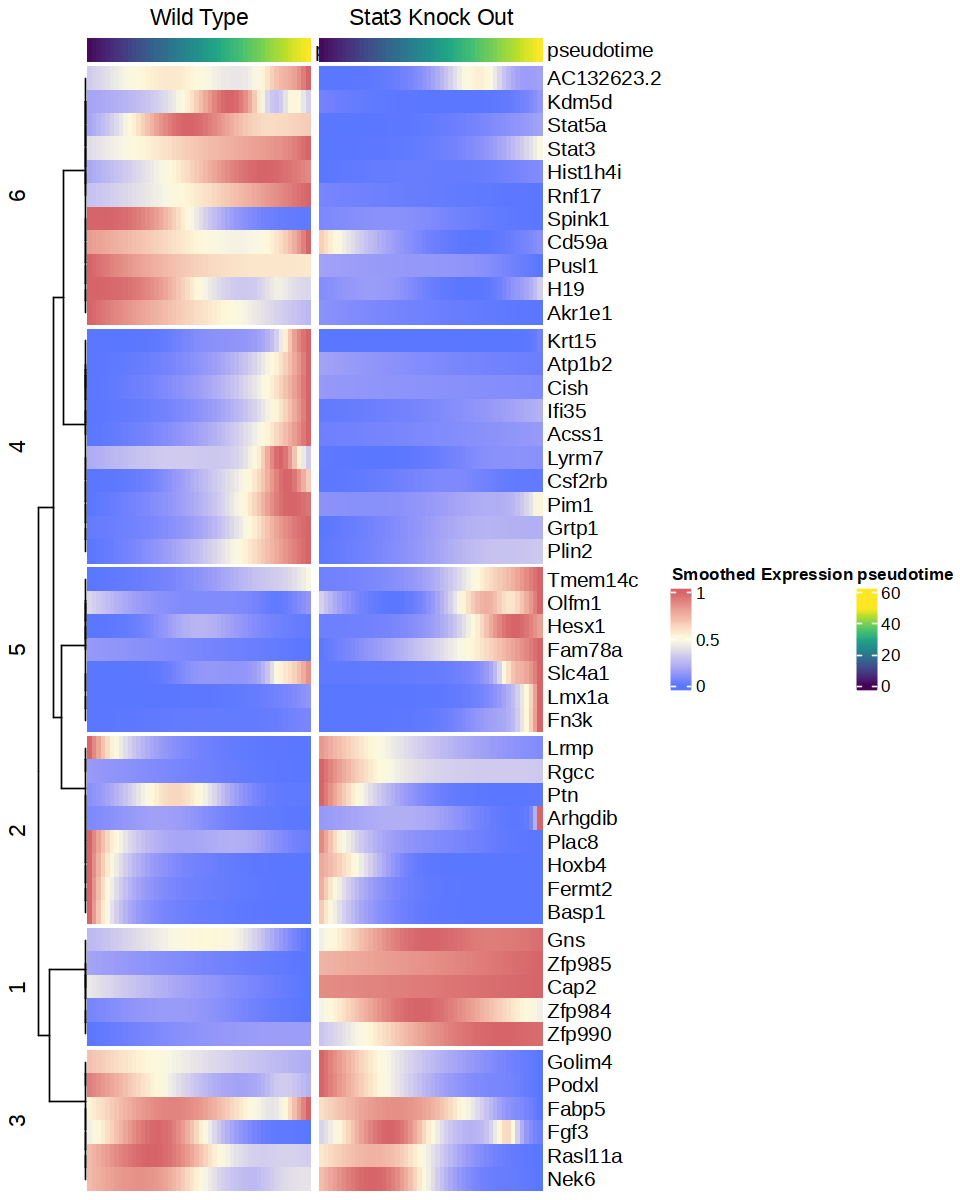

In [355]:
yhatSmooth <- predictSmooth(sceGAM, gene = conditionGenes, nPoints = 50, tidy = FALSE)
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 
WT = yhatSmooth_minmax[, grepl('FALSE', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('TRUE', colnames(yhatSmooth_minmax))]

# Clustering
k = 6
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'Wild Type',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Stat3 Knock Out',
                  show_column_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)
options(repr.plot.height=10, repr.plot.width=8)
draw(hm_list)

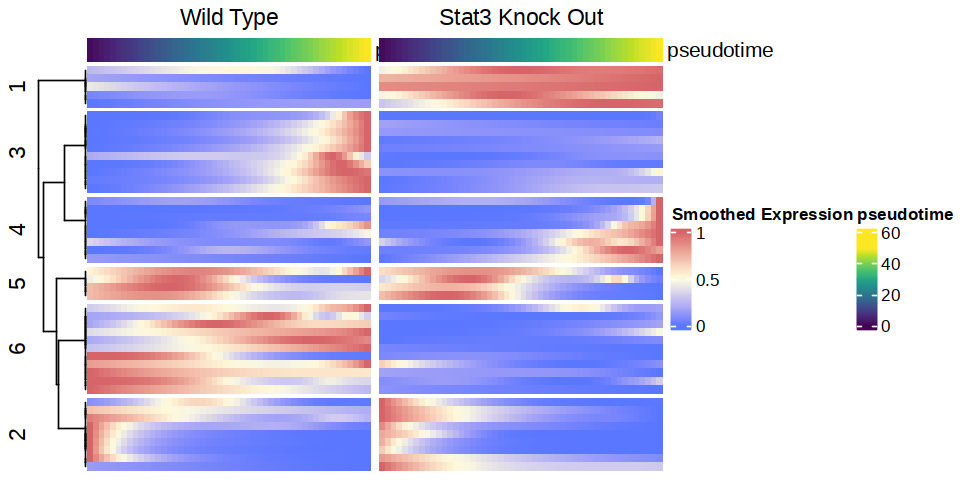

In [242]:
hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'Wild Type',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Stat3 Knock Out',
                  show_column_names  = FALSE,
                  show_row_names = FALSE, 
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)
options(repr.plot.height=4, repr.plot.width=8)
draw(hm_list)

In [236]:
# Now combine clusters together in a single plot
smooth.dt = as.data.table(yhatSmooth_minmax, keep.rownames=T) %>% 
    setnames('rn', 'gene') %>% 
    melt(., id.vars = 'gene', variable.names = 'column', value.names= 'value') %>%
    .[,tdTom := ifelse(grepl('FALSE', variable), 'WT', 'Stat3 KO')] %>%
    .[,tdTom := factor(tdTom, levels=c('WT', 'Stat3 KO'))] %>%
    .[,pseudotime := as.numeric(gsub('point', '', str_split(variable, '_') %>% map_chr(3)))] %>% 
    merge(., 
          as.data.table(group, keep.rownames=T) %>% setnames('rn', 'gene'),
          by='gene') 

mean.dt = smooth.dt %>% copy() %>% 
    .[,value := mean(value), by=c('group', 'tdTom', 'pseudotime')] %>% 
    unique(by=c('group', 'tdTom', 'pseudotime'))

nrow(smooth.dt)
nrow(mean.dt)

[1] 4700

[1] 600

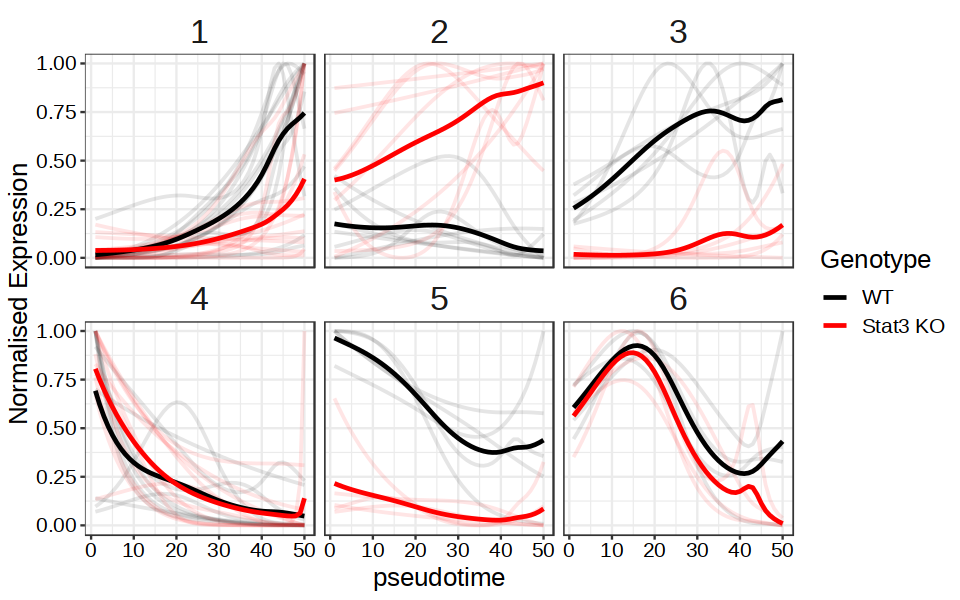

In [237]:
options(repr.plot.height=5, repr.plot.width=8)
ggplot(smooth.dt, aes(pseudotime, value, col=tdTom, group.by=gene)) + 
    geom_line(alpha=0.1, size=0.8) +
    geom_line(data=mean.dt, size=1) + 
    scale_color_manual(values=c('WT' = 'black', 'Stat3 KO' = 'red'), name='Genotype') + 
    facet_wrap(~group) + 
    ylab('Normalised Expression') + 
    theme_bw() + 
    theme(strip.background=element_blank(),
          strip.text = element_text(size=20), 
         text = element_text(size=15, color='black'),
         axis.text = element_text(color='black'))

In [359]:
genes = c('Stat3', 
          'Stat5a',
          'Cish', # canonical Stat3 target
          'Pim1', # canonical Stat3 target
          'Ifi35', # interferon induced
          'Plin2', # ?
          'Krt15', # ? Krt18 is a erythroid stem cell markers (?)
          'Cd59a' # plays a role in complement response, not described in erythroids
         )
options(repr.plot.width = 10, repr.plot.height=5)
plots = mclapply(genes, function(x){
        p = plot_traj(x, size=0.01, alpha=0.1) + 
                scale_x_continuous(breaks = seq(0, 50, by = 25)) + 
                theme(axis.title=element_blank(),
                      axis.text.x=element_text(color='black'),
                      axis.text.y=element_text(color='black'))
    }, mc.cores=24) 
p = ggarrange(plotlist=plots, nrow=2, ncol=4, common.legend=TRUE, legend="right")

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


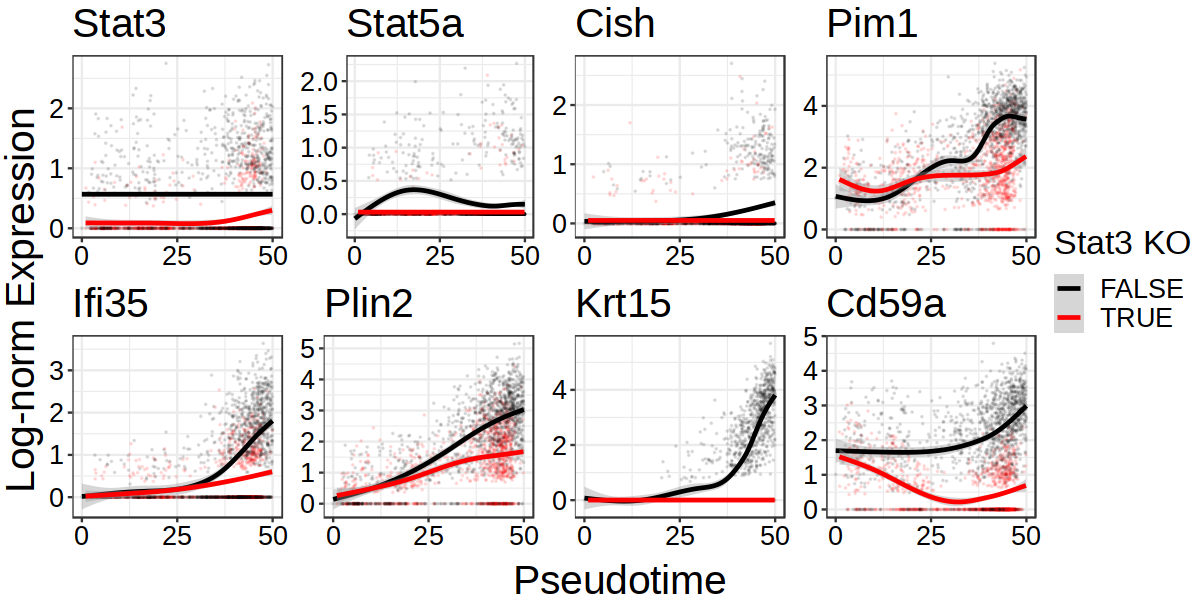

In [360]:
annotate_figure(p, left = textGrob("Log-norm Expression", rot = 90, vjust = 0.5, hjust=0.5, gp = gpar(cex = 2)),
                    bottom = textGrob("Pseudotime", gp = gpar(cex = 2)))

In [348]:
group[order(group)]

Zfp985     Zfp984       Cap2     Zfp990        Gns       Lrmp     Fermt2 
         1          1          1          1          1          2          2 
     Basp1      Hoxb4      Plac8       Rgcc     Golim4      Podxl        Ptn 
         2          2          2          2          2          2          2 
    Csf2rb      Ifi35       Pim1     Atp1b2       Cish      Lyrm7      Grtp1 
         3          3          3          3          3          3          3 
     Plin2      Acss1      Krt15      Lmx1a      Olfm1      Hesx1    Arhgdib 
         3          3          3          4          4          4          4 
      Fn3k     Fam78a    Tmem14c     Slc4a1       Fgf3      Fabp5    Rasl11a 
         4          4          4          4          5          5          5 
      Nek6      Cd59a        H19     Akr1e1      Pusl1   Hist1h4i      Stat3 
         5          6          6          6          6          6          6 
    Stat5a      Kdm5d AC132623.2      Rnf17     Spink1 
         6          6          6          6          6

In [349]:
length(group)

[1] 47

In [350]:
genes = names(group)
options(repr.plot.width = 15, repr.plot.height=25)
plots = mclapply(genes, function(x){
        p = plot_traj(x, size=0.01, alpha=0.1) + 
                scale_x_continuous(breaks = seq(0, 50, by = 25)) + 
                theme(axis.title=element_blank(),
                      axis.text.x=element_text(color='black'),
                      axis.text.y=element_text(color='black'))
    }, mc.cores=24) 
p = ggarrange(plotlist=plots, nrow=10, ncol=5, common.legend=TRUE, legend="right")

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 

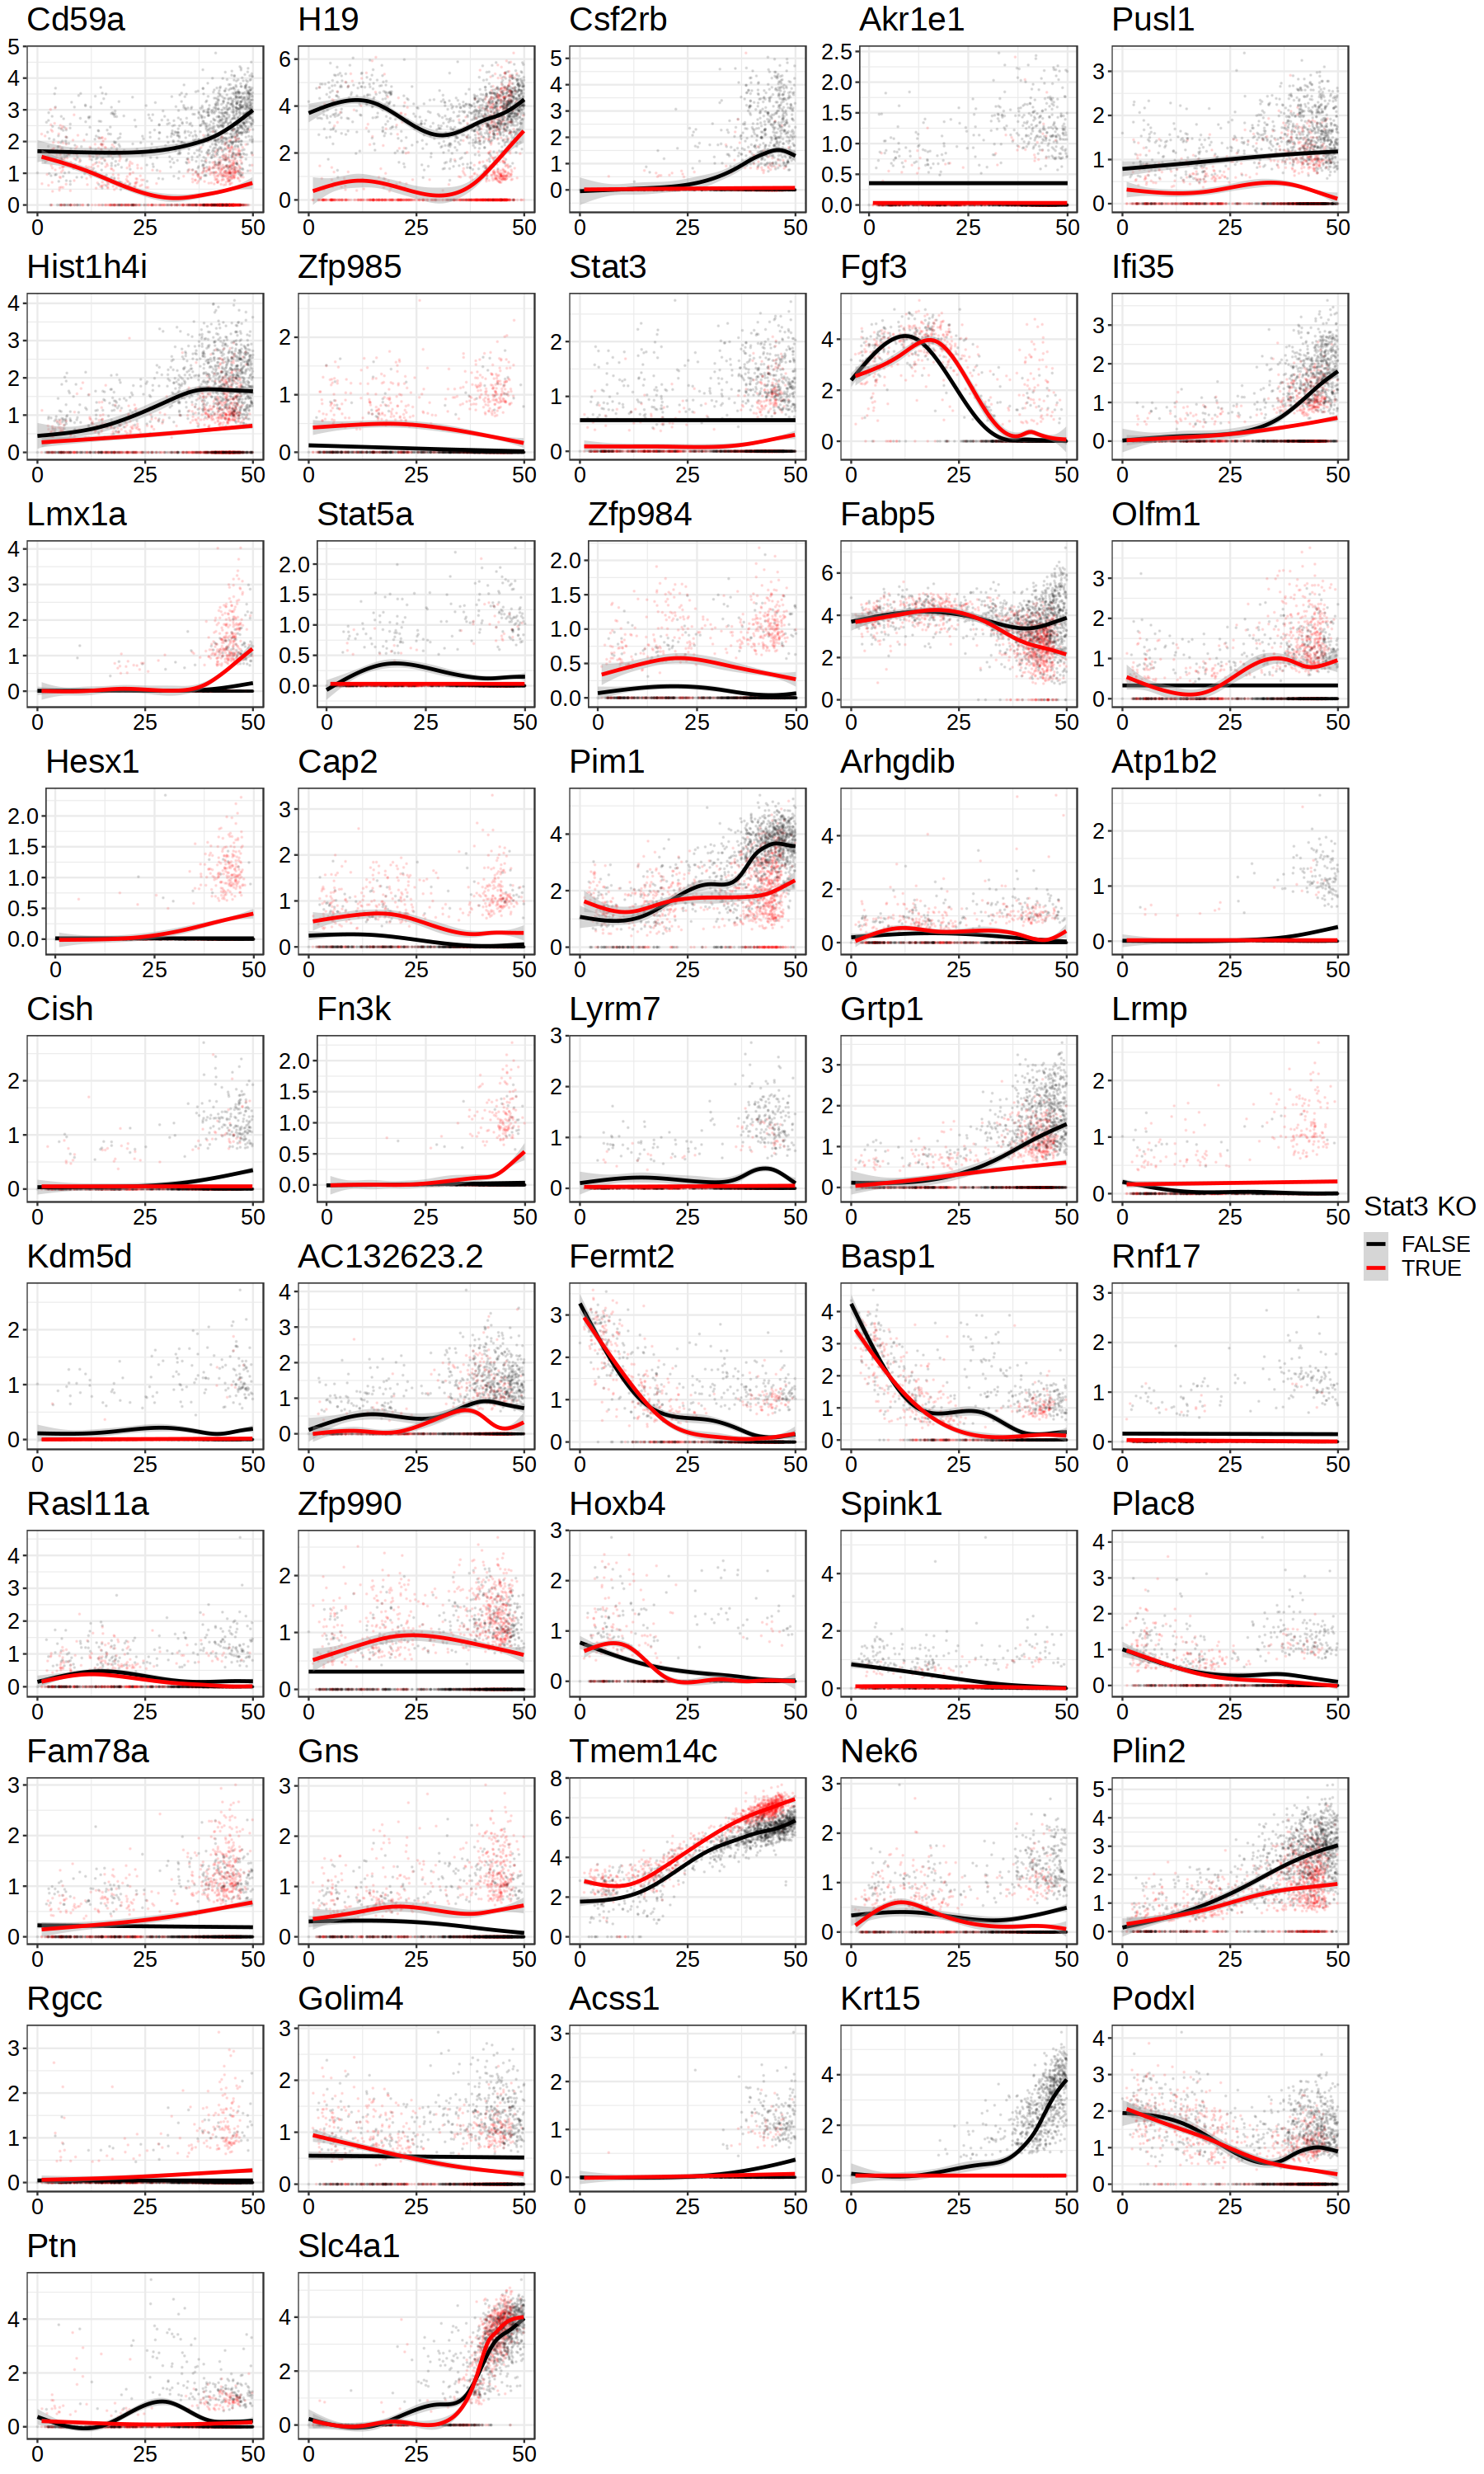

In [351]:
p

In [352]:
genes = c('Stat5b', 'Rragd', 'Cd24a')
options(repr.plot.width = 15, repr.plot.height=25)
plots = mclapply(genes, function(x){
        p = plot_traj(x, size=0.01, alpha=0.1) + 
                scale_x_continuous(breaks = seq(0, 50, by = 25)) + 
                theme(axis.title=element_blank(),
                      axis.text.x=element_text(color='black'),
                      axis.text.y=element_text(color='black'))
    }, mc.cores=24) 
p = ggarrange(plotlist=plots, nrow=10, ncol=5, common.legend=TRUE, legend="right")

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


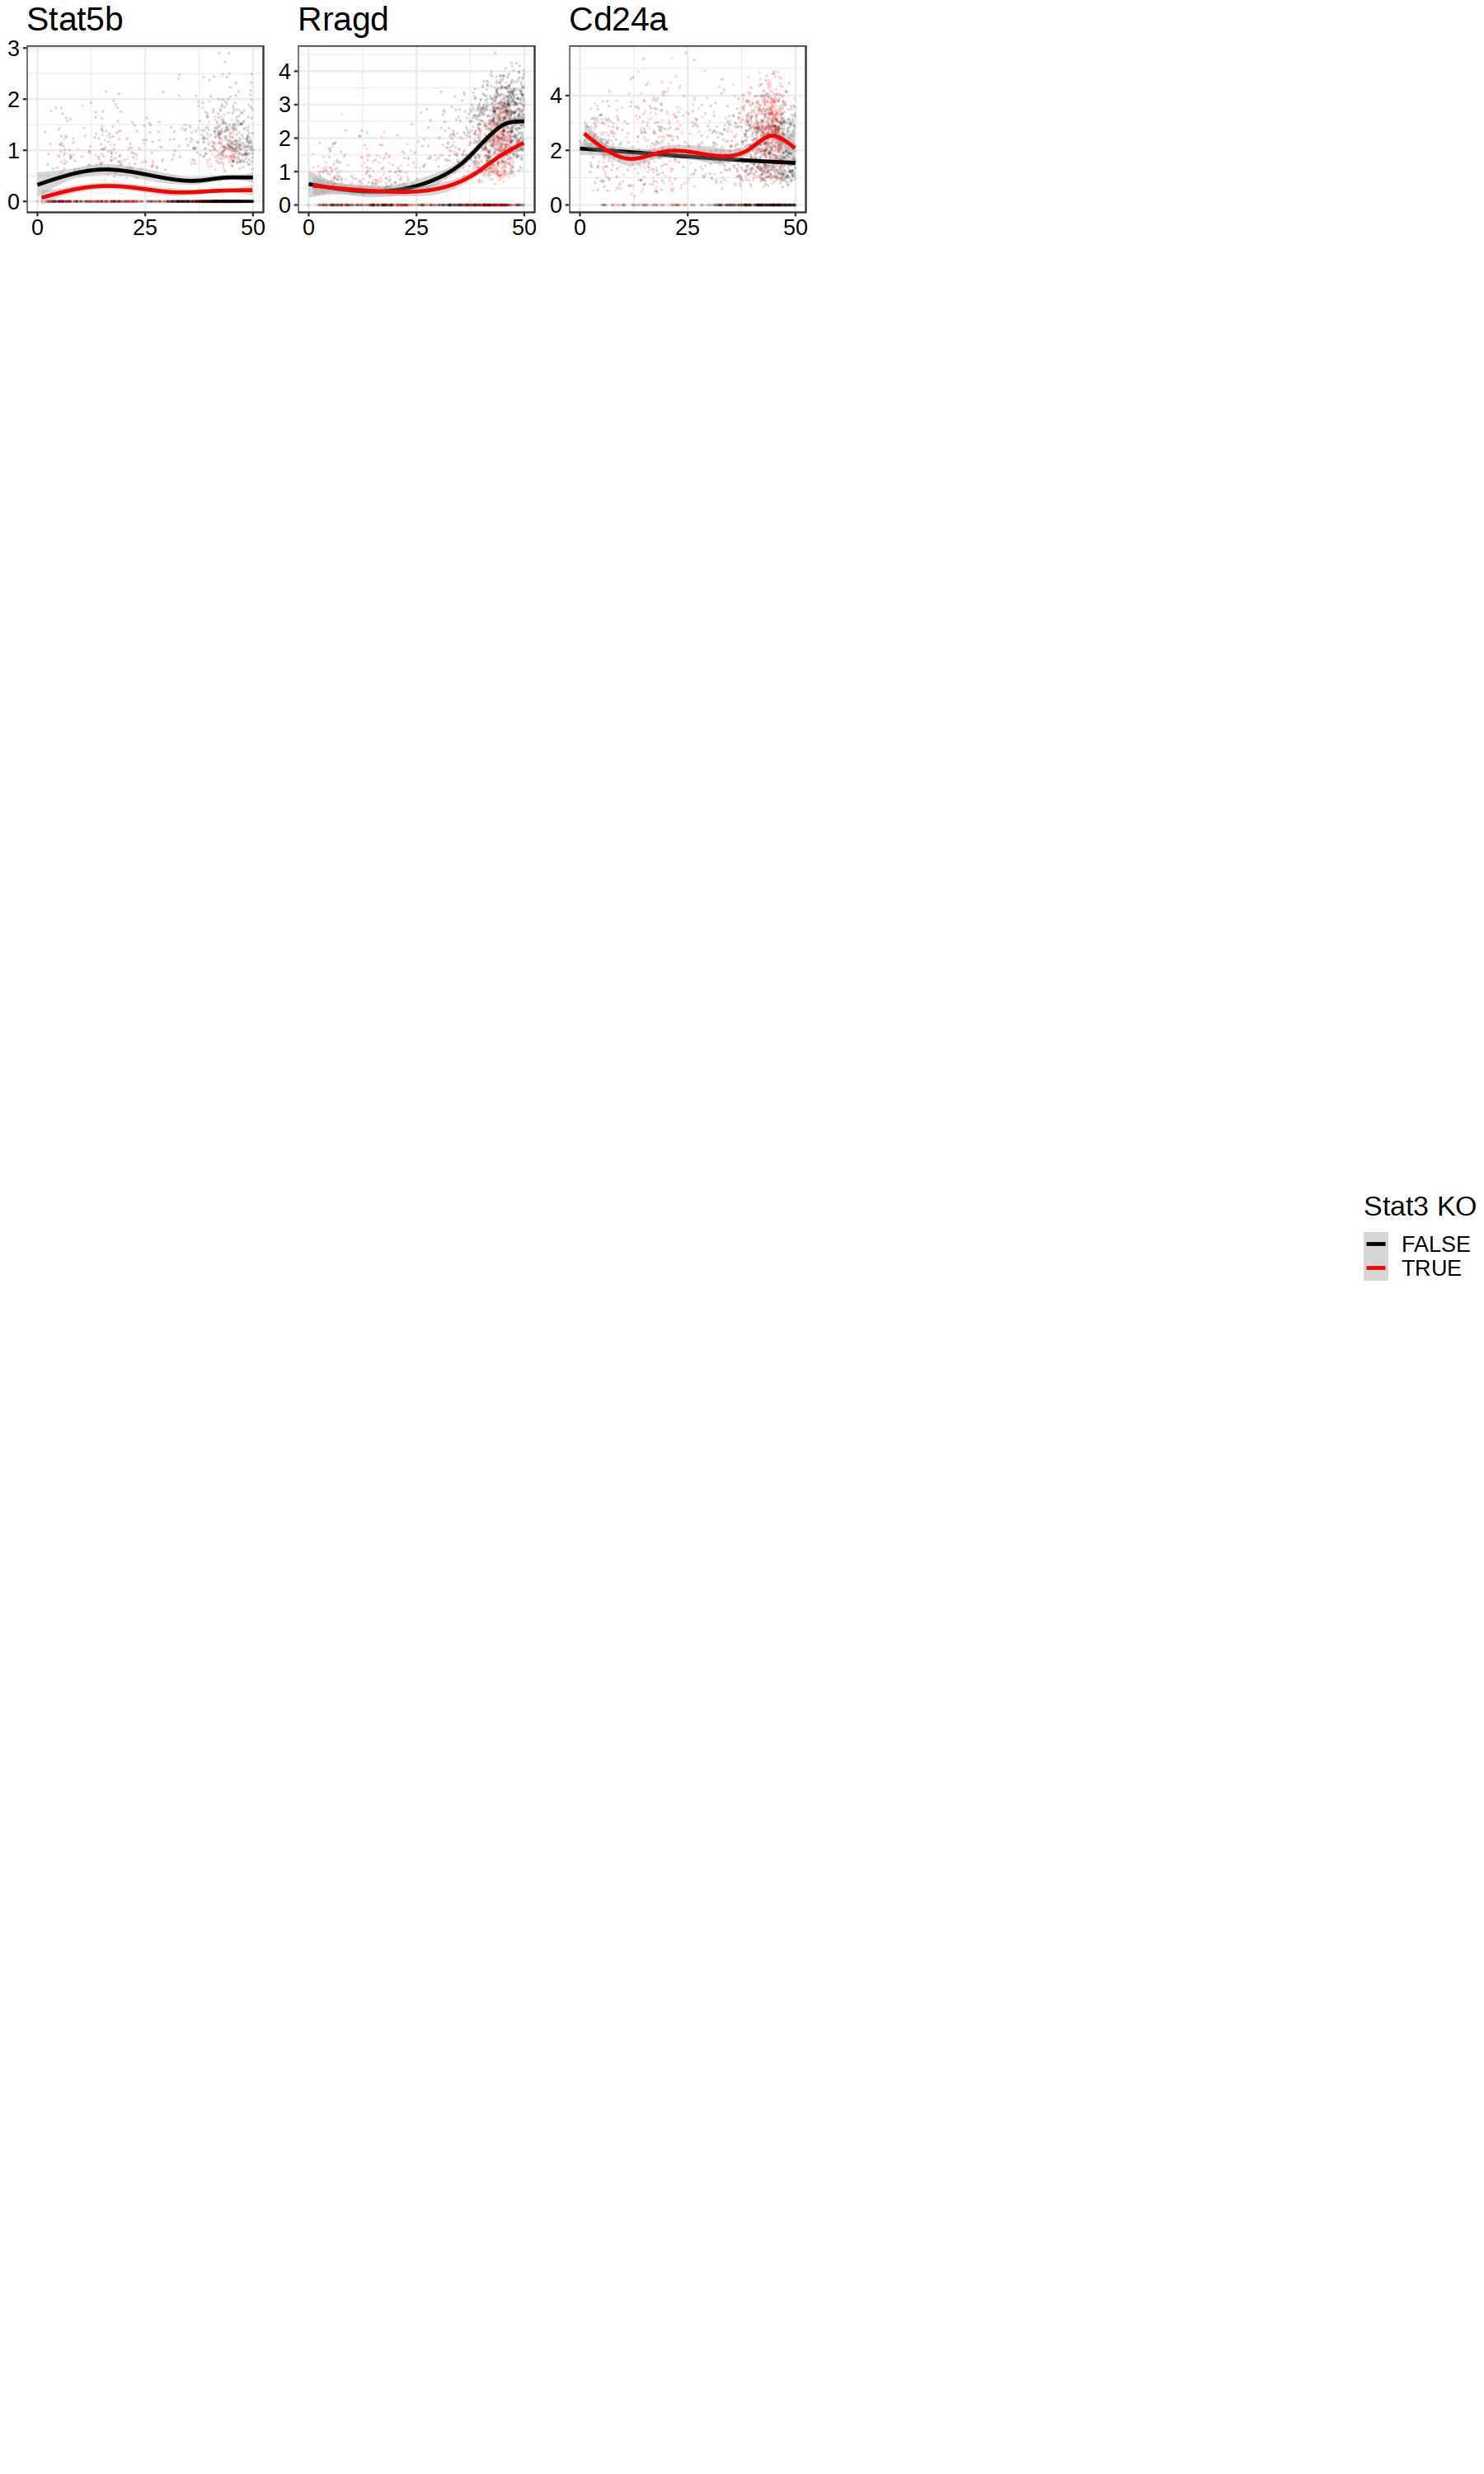

In [353]:
p

In [75]:
#### Same but from log counts 

# # Get log counts
# logcounts = as.data.table(as.matrix(logcounts(sce_filt[conditionGenes,])), keep.rownames=T) %>% setnames('rn', 'gene')
# # wide to long
# long = melt(logcounts, id.vars = c("gene"),
#                variable.name = "cell", value.name = "Expr")

# # Annotate pseudotime bin & condition
# meta = as.data.table(colData(sce_filt)[,-20], keep.rownames=T) %>%
#     setnames('rn', 'cell') %>% 
#     .[,c('cell', 'pseudotime','tdTom_corr')] %>% # ,'celltype.mapped_mnn', 'stage'
#     .[,pseudotime_bin:=cut(pseudotime, 50)] %>%
#     .[match(long$cell, cell),]

# long = cbind(long, meta[,-'cell'])

# # mean per pseudotime bin & condition
# long = long %>% 
#    # .[,Expr := (Expr-min(Expr))/(max(Expr)-min(Expr)), by='gene'] %>%  # minmax normalisation
#     .[,mean_expr := mean(Expr), by=c('gene','pseudotime_bin', 'tdTom_corr')] %>% 
#     #.[,mean_expr := scale(mean_expr), by='gene'] %>%  # scaling
#     .[,mean_expr := (mean_expr-min(mean_expr))/(max(mean_expr)-min(mean_expr)), by='gene'] %>%  # minmax normalisation
#     unique(by=c('gene', 'pseudotime_bin', 'tdTom_corr')) %>% 
#     .[order(pseudotime_bin),] %>%
#     .[,mean_expr_roll := frollmean(mean_expr, 3, align = 'right'), by=c('gene', 'tdTom_corr')] %>% .[,mean_expr_roll := ifelse(is.na(mean_expr_roll), mean_expr, mean_expr_roll)]


# # smooth using rolling average?

# # split by condition
# WT = long[tdTom_corr==FALSE,c('gene','pseudotime_bin', 'mean_expr')] %>%
#     dcast(., gene ~ pseudotime_bin, value.var='mean_expr') %>%
#    as.data.frame() %>% tibble::column_to_rownames('gene') %>% as.matrix

# KO = long[tdTom_corr==TRUE,c('gene','pseudotime_bin', 'mean_expr')]  %>% 
#     dcast(., gene ~ pseudotime_bin, value.var='mean_expr') %>%
#     as.data.frame() %>% tibble::column_to_rownames('gene') %>% as.matrix

# # head(logcounts)
# # head(long)
# # head(WT)

# summary(colnames(WT) == colnames(KO))

# options(repr.plot.height=4)

# ggplot(long[gene=='Cd59a',], aes(pseudotime_bin, mean_expr, col=tdTom_corr, group=tdTom_corr)) + 
#         geom_point(size=0.2, alpha=0.3) + 
#         geom_line() + 
#         scale_colour_manual(values=c('TRUE'='red', 'FALSE'='black'), name='Stat3 KO') + 
#         ylab('logcounts') + 
#         xlab('Pseudotime') + 
#         theme_bw() + 
#         theme(text=element_text(size=20))

# hm_list = Heatmap(WT, 
#                   cluster_columns = FALSE,
#                   column_title = 'Wild Type',
#                   show_column_names  = FALSE) + 
#           Heatmap(KO, 
#                   cluster_columns = FALSE, 
#                   column_title = 'Stat3 Knock Out')

# options(repr.plot.height=15)

# draw(hm_list)